# Clasificación de Imágenes: ¿IA o Real?

Este notebook aborda el problema de distinguir entre imágenes generadas por inteligencia artificial y fotografías o arte real, utilizando técnicas de deep learning y el dataset AI-Generated-vs-Real-Images-Datasets.

---

## 1. Importar librerías necesarias

In [17]:
# Importar librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from datasets import load_dataset
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
import torchvision
import torchvision.transforms as transforms
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
import random
import os

# Configuración para reproducibilidad
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(42)

# Comprobar si hay GPU disponible
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")

Usando dispositivo: cpu


## 2. Descargar y cargar el dataset desde HuggingFace

Utilizaremos la librería `datasets` para descargar y cargar el dataset 'Hemg/AI-Generated-vs-Real-Images-Datasets'.

In [18]:
# Descargar y cargar el dataset
dataset = load_dataset("Hemg/AI-Generated-vs-Real-Images-Datasets")

# Mostrar información básica del dataset
print(dataset)
print("Ejemplo de registro:")
print(dataset['train'][0])

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 152710
    })
})
Ejemplo de registro:
{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=880x440 at 0x17F9D4BDCD0>, 'label': 0}


## 3. Exploración y visualización inicial de datos

Mostraremos ejemplos de imágenes de ambas clases, la distribución de etiquetas y algunas estadísticas básicas del dataset.

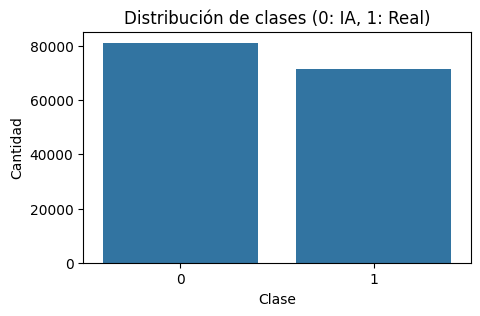

In [ ]:
# Visualizar la distribución de etiquetas
y_labels = [item['label'] for item in dataset['train']]
plt.figure(figsize=(5,3))
sns.countplot(x=y_labels)
plt.title('Distribución de clases (0: IA, 1: Real)')
plt.xlabel('Clase')
plt.ylabel('Cantidad')
plt.show()

# Mostrar ejemplos de imágenes de ambas clases
def show_examples(ds, n=4):
    fig, axes = plt.subplots(1, n, figsize=(15,4))
    count = 0
    for i, item in enumerate(ds):
        if count >= n:
            break
        img = item['image']
        label = item['label']
        axes[count].imshow(img)
        axes[count].set_title(f"Label: {label}")
        axes[count].axis('off')
        count += 1
    plt.show()


Ejemplos de imágenes generadas por IA (label=0):


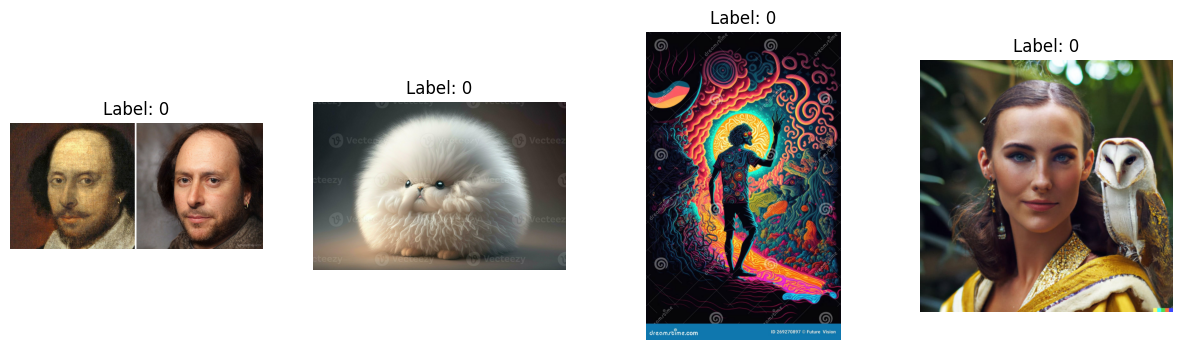

In [5]:

print("Ejemplos de imágenes generadas por IA (label=0):")
show_examples([item for item in dataset['train'] if item['label']==0][:4])


Ejemplos de imágenes reales (label=1):


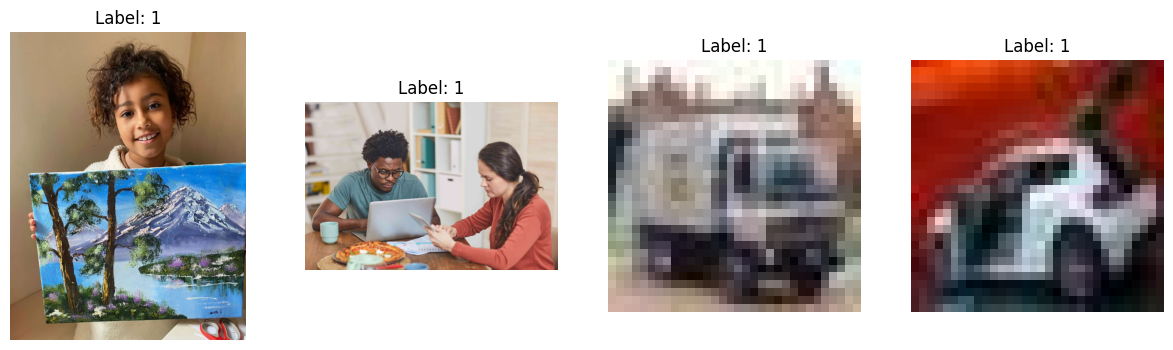

In [6]:
print("Ejemplos de imágenes reales (label=1):")
show_examples([item for item in dataset['train'] if item['label']==1][:4])

## 4. Preprocesamiento de imágenes

Incluye redimensionamiento a 224x224, normalización (valores de ImageNet) y data augmentation (rotaciones, flips, cambios de brillo/contraste, recortes aleatorios).

In [19]:
import torch
from torch.utils.data import Dataset
from torchvision import transforms

# Definir transformaciones
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

# Dataset personalizado
class CustomImageDataset(Dataset):
    def __init__(self, data, transform=None):
        self.data = data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img = self.data[idx]['image']
        label = self.data[idx]['label']

        if self.transform:
            img = self.transform(img)

        return img, label

## 5. División del dataset en train/val/test

Dividimos el dataset en conjuntos de entrenamiento, validación y test (80/10/10) y mostramos el tamaño de cada split.

In [20]:
from PIL import Image, UnidentifiedImageError
from datasets import Image as HFImage
from io import BytesIO
import numpy as np
from torch.utils.data import Dataset as TorchDataset, DataLoader

def safe_load_image(example):
    try:
        img = example['image']
        img.load()
        return True
    except (OSError, UnidentifiedImageError):
        return False

full_data = dataset['train'].filter(safe_load_image)

# CLAVE: evitar decodificación automática de HuggingFace
full_data = full_data.cast_column('image', HFImage(decode=False))

print(f"Dataset limpio: {len(full_data)}")

splits = full_data.train_test_split(test_size=0.2, seed=42)

train_val = splits['train']
test_data = splits['test']

val_split = train_val.train_test_split(test_size=0.125, seed=42)

train_data = val_split['train']
val_data = val_split['test']

print(f"Train: {len(train_data)}")
print(f"Val: {len(val_data)}")
print(f"Test: {len(test_data)}")

class CustomImageDataset(TorchDataset):
    def __init__(self, hf_dataset, transform=None):
        self.dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        for _ in range(len(self.dataset)):
            example = self.dataset[idx]
            try:
                img_data = example['image']
                if img_data is None:
                    raise ValueError('Imagen vacia')

                if isinstance(img_data, dict):
                    if img_data.get('bytes') is not None:
                        image = Image.open(BytesIO(img_data['bytes']))
                    elif img_data.get('path') is not None:
                        image = Image.open(img_data['path'])
                    else:
                        raise ValueError('Formato de imagen desconocido')
                else:
                    image = img_data

                image = image.convert('RGB')

                if self.transform:
                    image = self.transform(image)

                label = example['label']
                return image, label
            except Exception:
                idx = (idx + 1) % len(self.dataset)

        raise RuntimeError('No se pudo cargar ninguna imagen valida en el dataset.')

batch_size = 64
num_workers = 0 
pin_memory = device.type == 'cuda'

train_dataset = CustomImageDataset(train_data, transform=train_transform)
val_dataset = CustomImageDataset(val_data, transform=val_test_transform)
test_dataset = CustomImageDataset(test_data, transform=val_test_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_memory
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory
)

print(f'DataLoaders listos sin errores (num_workers={num_workers})')

Dataset limpio: 152710
Train: 106897
Val: 15271
Test: 30542
DataLoaders listos sin errores (num_workers=0)


## 6. Definición de arquitecturas de modelos

Definimos una CNN simple como baseline y preparamos la configuración para arquitecturas avanzadas como ResNet y EfficientNet, incluyendo la opción de transfer learning.

In [21]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x.squeeze()

# Arquitectura avanzada: ResNet18
from torchvision.models import resnet18, ResNet18_Weights

def get_resnet18(pretrained=True):
    model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1 if pretrained else None)
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(num_ftrs, 1),
        nn.Sigmoid()
    )
    return model

# EfficientNetB0 (opcional, requiere torchvision >= 0.13)
try:
    from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
    def get_efficientnet(pretrained=True):
        model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None)
        num_ftrs = model.classifier[1].in_features
        model.classifier[1] = nn.Sequential(
            nn.Linear(num_ftrs, 1),
            nn.Sigmoid()
        )
        return model
except ImportError:
    print("EfficientNet no disponible en esta versión de torchvision.")

## 7. Entrenamiento del modelo base (CNN simple)

Entrenamos la CNN simple en el conjunto de entrenamiento, mostrando el progreso de la pérdida y la precisión.

1. Configuración del entrenamiento

In [12]:
num_epochs = 5
model = SimpleCNN().to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

train_losses, val_losses, val_accuracies = [], [], []

2. Función para entrenar una época

In [13]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.float().to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    return running_loss / len(loader.dataset)

3. Función para validar

In [14]:
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    preds, targets = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.float().to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds.extend((outputs.cpu().numpy() > 0.5).astype(int))
            targets.extend(labels.cpu().numpy().astype(int))

    epoch_loss = running_loss / len(loader.dataset)
    acc = accuracy_score(targets, preds)

    return epoch_loss, acc

4. Loop principal de entrenamiento

In [ ]:
for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f} - Val Acc: {val_acc:.4f}")

In [ ]:
import time
from itertools import islice

print(f'device={device}')
print(f'train_batches={len(train_loader)}, val_batches={len(val_loader)}')

train_probe_batches = min(20, len(train_loader))
val_probe_batches = min(20, len(val_loader))

model.train()
start = time.perf_counter()
for images, labels in islice(train_loader, train_probe_batches):
    images, labels = images.to(device), labels.float().to(device)
    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
train_elapsed = time.perf_counter() - start

model.eval()
start = time.perf_counter()
with torch.no_grad():
    for images, labels in islice(val_loader, val_probe_batches):
        images, labels = images.to(device), labels.float().to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
val_elapsed = time.perf_counter() - start

train_per_batch = train_elapsed / train_probe_batches
val_per_batch = val_elapsed / val_probe_batches
estimated_epoch_seconds = train_per_batch * len(train_loader) + val_per_batch * len(val_loader)

print(f'train_probe: {train_elapsed:.2f}s para {train_probe_batches} batches')
print(f'val_probe: {val_elapsed:.2f}s para {val_probe_batches} batches')
print(f'estimado por epoca: {estimated_epoch_seconds / 60:.2f} min')
print(f'estimado para {num_epochs} epocas: {(estimated_epoch_seconds * num_epochs) / 60:.2f} min')

device=cpu
train_batches=1671, val_batches=239
train_probe: 158.76s para 20 batches
val_probe: 38.12s para 20 batches
estimado por epoca: 228.66 min
estimado para 5 epocas: 1143.29 min


5. Gráficas

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title('Curva de pérdida')

plt.subplot(1,2,2)
plt.plot(val_accuracies, label='Val Accuracy')
plt.legend()
plt.title('Precisión en validación')

plt.show()

## 8. Evaluación del modelo base

Evaluamos el modelo simple en los conjuntos de validación y test, mostrando métricas como accuracy, precision, recall, F1-score y matriz de confusión.

In [ ]:
# Evaluación en test set
def evaluate_model(model, loader):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.float().to(device)
            outputs = model(images)
            preds.extend((outputs.cpu().numpy() > 0.5).astype(int))
            targets.extend(labels.cpu().numpy().astype(int))
    return np.array(preds), np.array(targets)

preds, targets = evaluate_model(model, test_loader)
print(classification_report(targets, preds, target_names=["IA", "Real"]))
cm = confusion_matrix(targets, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["IA", "Real"], yticklabels=["IA", "Real"])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de confusión - CNN simple')
plt.show()

## 9. Entrenamiento con arquitectura avanzada (ResNet18)

Entrenamos un modelo avanzado (ResNet18) desde cero o con pesos preentrenados, mostrando el progreso del entrenamiento.

In [ ]:
resnet_model = get_resnet18(pretrained=True).to(device)

criterion = nn.BCEWithLogitsLoss()  #  mejor que BCELoss
optimizer = optim.Adam(resnet_model.parameters(), lr=1e-4)

num_epochs = 5
train_losses, val_losses, val_accuracies = [], [], []

for epoch in range(num_epochs):
    resnet_model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)  # FIX

        optimizer.zero_grad()
        outputs = resnet_model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    # VALIDACIÓN
    resnet_model.eval()
    val_loss = 0.0
    preds, targets = [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            outputs = resnet_model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)

            probs = torch.sigmoid(outputs)
            preds.extend((probs.cpu().numpy() > 0.5).astype(int))
            targets.extend(labels.cpu().numpy().astype(int))

    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)

    acc = accuracy_score(targets, preds)
    val_accuracies.append(acc)

    print(f"[ResNet18] Epoch {epoch+1}/{num_epochs} - Train Loss: {epoch_loss:.4f} - Val Loss: {val_loss:.4f} - Val Acc: {acc:.4f}")

# GRÁFICAS
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title('Curva de pérdida (ResNet18)')

plt.subplot(1,2,2)
plt.plot(val_accuracies, label='Val Accuracy')
plt.legend()
plt.title('Precisión en validación (ResNet18)')

plt.show()

## 10. Transfer Learning y fine-tuning

Implementamos transfer learning usando un modelo preentrenado (ResNet50), reemplazando la última capa y afinando las últimas capas.

In [ ]:
from torchvision.models import resnet50, ResNet50_Weights
import torch.nn as nn
import torch.optim as optim

# Cargar modelo preentrenado
resnet50_model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)

# Congelar capas
for param in resnet50_model.parameters():
    param.requires_grad = False

# Reemplazar última capa
num_ftrs = resnet50_model.fc.in_features
resnet50_model.fc = nn.Sequential(
    nn.Linear(num_ftrs, 1),
    nn.Sigmoid()
)

# Entrenar solo la última capa
for param in resnet50_model.fc.parameters():
    param.requires_grad = True

resnet50_model = resnet50_model.to(device)

criterion = nn.BCELoss()
optimizer = optim.Adam(resnet50_model.fc.parameters(), lr=1e-4)

num_epochs = 3

for epoch in range(num_epochs):
    resnet50_model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)  #

        optimizer.zero_grad()
        outputs = resnet50_model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"[ResNet50 Transfer] Epoch {epoch+1}/{num_epochs} - Train Loss: {epoch_loss:.4f}")

## 11. Evaluación y comparación de modelos

Comparamos el desempeño de los diferentes modelos (CNN simple, ResNet18, transfer learning) usando métricas y visualizaciones.

In [ ]:
# Evaluación de ResNet18 y ResNet50 transfer learning
def evaluate_and_report(model, loader, model_name):
    preds, targets = evaluate_model(model, loader)
    print(f"\nReporte para {model_name}:")
    print(classification_report(targets, preds, target_names=["IA", "Real"]))
    cm = confusion_matrix(targets, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["IA", "Real"], yticklabels=["IA", "Real"])
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.title(f'Matriz de confusión - {model_name}')
    plt.show()

print("Evaluación ResNet18:")
evaluate_and_report(resnet_model, test_loader, "ResNet18")

print("Evaluación ResNet50 Transfer Learning:")
evaluate_and_report(resnet50_model, test_loader, "ResNet50 Transfer Learning")

## 12. Visualización de resultados y métricas

Generamos gráficos de curvas de aprendizaje, matriz de confusión, ejemplos de predicciones correctas/incorrectas y análisis de errores.

In [ ]:
# Ejemplos de predicciones correctas e incorrectas (ResNet50)
resnet50_model.eval()
examples = []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.cpu().numpy()
        outputs = resnet50_model(images).cpu().numpy().flatten()
        preds = (outputs > 0.5).astype(int)
        for i in range(len(images)):
            examples.append((images[i].cpu(), preds[i], labels[i]))
        if len(examples) > 12:
            break

fig, axes = plt.subplots(3, 4, figsize=(15, 10))
for idx, (img, pred, label) in enumerate(examples[:12]):
    ax = axes[idx//4, idx%4]
    img = img.permute(1,2,0) * torch.tensor(imagenet_std) + torch.tensor(imagenet_mean)
    img = img.numpy().clip(0,1)
    ax.imshow(img)
    ax.set_title(f"Pred: {pred} | Real: {label}", color='green' if pred==label else 'red')
    ax.axis('off')
plt.suptitle('Ejemplos de predicciones (verde: correcto, rojo: error)')
plt.show()